# Results Analysis

Load the latest evaluation record for each model from `results/`.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from utils import TFLiteEvalRecord

repo_root = Path.cwd().parent
results_dir = repo_root / "results"

records = []
for p in sorted(results_dir.glob("*.jsonl")):
    with p.open("r", encoding="utf-8") as f:
        lines = f.readlines()
    if not lines:
        continue
    last = json.loads(lines[-1])
    records.append(TFLiteEvalRecord.model_validate(last))

records = sorted(records, key=lambda r: r.model_name)
print(f"Loaded {len(records)} runs from {results_dir}")


Loaded 7 runs from /home/nathan/Documents/tiny-chirp-microflow/results


ROC curves (computed on train set).

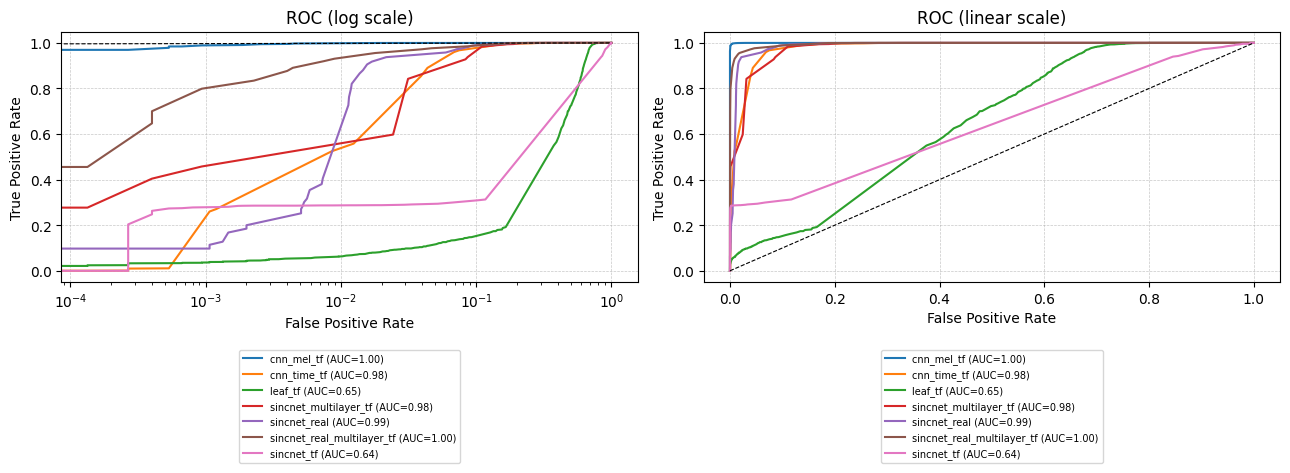

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for rec in records:
    if rec.train.roc_fpr is None or rec.train.roc_tpr is None or rec.train.auc is None:
        continue
    label = f"{rec.model_name} (AUC={rec.train.auc:.2f})"
    for ax in axes:
        ax.plot(rec.train.roc_fpr, rec.train.roc_tpr, label=label)

for ax, xscale, title in zip(axes, ["log", "linear"], ["ROC (log scale)", "ROC (linear scale)"]):
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_xscale(xscale)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), fontsize=7)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.show()


# Table IV — threshold and prediction metrics on **training set**.

In [3]:
rows = []
for rec in records:
    m = rec.train
    rows.append(
        {
            "Model": rec.model_name,
            "Threshold (t)": m.threshold,
            "Acc.": m.accuracy,
            "Precision": m.precision,
            "Recall": m.recall,
            "F2": m.f2,
        }
    )

df_train = pd.DataFrame(rows).sort_values("Model")

df_train.style.format(
    {
        "Threshold (t)": "{:.2e}",
        "Acc.": "{:.2f}",
        "Precision": "{:.2f}",
        "Recall": "{:.2f}",
        "F2": "{:.2f}",
    }
)


,Model,Threshold (t),Acc.,Precision,Recall,F2
0,cnn_mel_tf,5.90e-01,1.00,0.99,1.00,1.00
1,cnn_time_tf,6.44e-01,0.94,0.87,0.97,0.95
2,leaf_tf,2.75e-05,0.52,0.41,0.99,0.77
3,sincnet_multilayer_tf,5.00e-01,0.92,0.82,0.98,0.95
4,sincnet_real,5.00e-01,0.93,0.84,0.99,0.96
5,sincnet_real_multilayer_tf,3.32e-01,0.96,0.91,0.98,0.96
6,sincnet_tf,9.22e-02,0.39,0.35,0.97,0.72


# Table V — prediction metrics on **test set**.

In [4]:
rows = []
for rec in records:
    m = rec.test
    rows.append(
        {
            "Model": rec.model_name,
            "Accuracy": m.accuracy,
            "Precision": m.precision,
            "Recall": m.recall,
            "F2": m.f2,
            "Avg Inference (ms)": m.avg_inference_time_ms if m.avg_inference_time_ms is not None else np.nan,
        }
    )

pd.DataFrame(rows).sort_values("Model").style.format(
    {
        "Accuracy": "{:.2f}",
        "Precision": "{:.2f}",
        "Recall": "{:.2f}",
        "F2": "{:.2f}",
        "Avg Inference (ms)": "{:.3f}",
    },
    na_rep="—",
)


,Model,Accuracy,Precision,Recall,F2,Avg Inference (ms)
0,cnn_mel_tf,0.98,0.94,1.00,0.98,0.981
1,cnn_time_tf,0.94,0.87,0.97,0.95,2.150
2,leaf_tf,0.52,0.41,0.98,0.77,13.817
3,sincnet_multilayer_tf,0.91,0.80,0.98,0.94,3.270
4,sincnet_real,0.93,0.83,0.99,0.95,2.139
5,sincnet_real_multilayer_tf,0.96,0.90,0.98,0.97,1.204
6,sincnet_tf,0.38,0.35,0.98,0.71,4.088


# Table VI — model characteristics (compute, RAM, flash).

In [5]:
rows = []
for rec in records:
    rows.append(
        {
            "Model": rec.model_name,
            "Est. MFLOPs": rec.flops_mflops if rec.flops_mflops is not None else np.nan,
            "Arena / RAM (KB)": rec.arena_size_kb if rec.arena_size_kb is not None else np.nan,
            "Flash (KB)": rec.model_size_kb if rec.model_size_kb is not None else np.nan,
            "Avg Inference (ms)": rec.test.avg_inference_time_ms if rec.test.avg_inference_time_ms is not None else np.nan,
        }
    )

pd.DataFrame(rows).sort_values("Model").style.format(
    {
        "Est. MFLOPs": "{:.3f}",
        "Arena / RAM (KB)": "{:.1f}",
        "Flash (KB)": "{:.1f}",
        "Avg Inference (ms)": "{:.3f}",
    },
    na_rep="—",
)

,Model,Est. MFLOPs,Arena / RAM (KB),Flash (KB),Avg Inference (ms)
0,cnn_mel_tf,0.349,—,25.1,0.981
1,cnn_time_tf,0.957,—,1.2,2.150
2,leaf_tf,1.577,4207.6,23.2,13.817
3,sincnet_multilayer_tf,1.710,—,15.2,3.270
4,sincnet_real,0.574,—,8.6,2.139
5,sincnet_real_multilayer_tf,0.268,—,9.8,1.204
6,sincnet_tf,0.672,560.6,5.7,4.088
